# Rank-first RaJIVE analysis with current rajiveplus API

This notebook is a refactor of `scratch/03_rajive_0504_MM.ipynb`. It starts with original-data QC, establishes a defensible RaJIVE decomposition and rank audit, then proceeds to exploratory component associations and exact-study `dream` contrasts.

Permutation-based joint-rank selection is treated as sensitivity-only here because the samples are longitudinal or paired. The primary rank fit uses Wedin plus random-direction bounds.


In [15]:
# Runtime controls -------------------------------------------------------------
DATA_PATHS <- list(
  cytof_celltype = "/exports/para-lipg-hpc/Xuran/data/cytof/analysis/clus_freq_clr_combat.csv",
  exvivo_celltype = "/exports/para-lipg-hpc/Xuran/data/aurora_exvivo/analysis/clus_freq_combat.csv",
  exvivo_enzyme = "/exports/para-lipg-hpc/Xuran/data/aurora_exvivo/analysis/enzyme_celltype_combat.csv",
  `6h_cyto_LPS` = "/exports/para-lipg-hpc/Xuran/data/aurora_6H/analysis/cytokine_pos_6hLPS_combat.csv",
  `6h_cyto_ssRNA40` = "/exports/para-lipg-hpc/Xuran/data/aurora_6H/analysis/cytokine_pos_6hssRNA40_combat.csv",
  `24h_cyto_iRBC` = "/exports/para-lipg-hpc/Xuran/data/aurora_24H/analysis/cytokine_pos_24hiRBC_combat.csv",
  `24h_cyto_SEB` = "/exports/para-lipg-hpc/Xuran/data/aurora_24H/analysis/cytokine_pos_24hSEB_combat.csv",
  `24h_enzyme_iRBC` = "/exports/para-lipg-hpc/Xuran/data/aurora_24H/analysis/enzyme_celltype_24hiRBC_combat.csv",
  `24h_enzyme_SEB` = "/exports/para-lipg-hpc/Xuran/data/aurora_24H/analysis/enzyme_celltype_24hSEB_combat.csv",
  `3d_cyto` = "/exports/para-lipg-hpc/Xuran/data/aurora_3D/analysis/cytokine_pos_combat.csv",
  `3d_enzyme` = "/exports/para-lipg-hpc/Xuran/data/aurora_3D/analysis/enzyme_celltype_combat.csv"
)
METADATA_PATH <- "/exports/para-lipg-hpc/Xuran/data/metadata.csv"

IMPUTATION_SEED <- 101L
RAJIVE_SEED <- 1L
RAJIVE_NUM_CORES <- 12L
PRIMARY_WEDIN_SAMPLES <- 5000L
PRIMARY_RAND_DIR_SAMPLES <- 5000L

RANK_STABILITY_B <- 100L
STABILITY_WEDIN_SAMPLES <- 1000L
STABILITY_RAND_DIR_SAMPLES <- 1000L
RANK_STABILITY_PASS_RATE <- 0.70

RUN_JACKSTRAW <- TRUE
JACKSTRAW_N_NULL <- 1000L
JACKSTRAW_ALPHA <- 0.001

RUN_SIMPLE_ASSOC_BOOTSTRAP <- FALSE
SIMPLE_ASSOC_BOOTSTRAP_B <- 50L

DREAM_CORES <- 6L
DREAM_MIN_GROUP_N <- 2L
RUN_ARRAY_WEIGHT_SENSITIVITY <- TRUE
FDR_ALPHA <- 0.10


In [16]:
# Package setup ----------------------------------------------------------------
find_repo_root <- function(start = getwd()) {
  path <- normalizePath(start, winslash = "/", mustWork = TRUE)
  repeat {
    desc <- file.path(path, "DESCRIPTION")
    if (file.exists(desc)) {
      fields <- tryCatch(read.dcf(desc), error = function(e) NULL)
      if (!is.null(fields) && "Package" %in% colnames(fields) &&
          identical(fields[1, "Package"], "rajiveplus")) {
        return(path)
      }
    }
    parent <- dirname(path)
    if (identical(parent, path)) break
    path <- parent
  }
  NA_character_
}

repo_root <- find_repo_root()
if (!is.na(repo_root)) {
  suppressPackageStartupMessages(devtools::load_all(repo_root, quiet = TRUE))
} else {
  suppressPackageStartupMessages(library(rajiveplus))
}

suppressPackageStartupMessages({
  library(tidyverse)
  library(patchwork)
  library(limma)
  library(variancePartition)
  library(lme4)
  library(BiocParallel)
})

RNGkind("L'Ecuyer-CMRG")
set.seed(RAJIVE_SEED)


## Helper layer

The helpers below are notebook-local by design. They make the analysis reproducible without expanding the package API.


In [17]:
`%||%` <- function(x, y) if (is.null(x)) y else x

safe_natural_sort <- function(x) {
  if (requireNamespace("naturalsort", quietly = TRUE)) {
    naturalsort::naturalsort(x)
  } else {
    sort(x)
  }
}

as_named_paths <- function(paths, object_name = "paths") {
  out <- vapply(paths, function(path) {
    if (!is.character(path) || length(path) != 1L || is.na(path)) {
      stop(object_name, " must contain one non-missing file path per entry.", call. = FALSE)
    }
    path
  }, character(1L), USE.NAMES = TRUE)
  if (is.null(names(out)) || any(!nzchar(names(out)))) {
    stop(object_name, " must be named.", call. = FALSE)
  }
  out
}

check_input_files <- function(paths, metadata_path) {
  paths <- as_named_paths(paths, "DATA_PATHS")
  if (!is.character(metadata_path) || length(metadata_path) != 1L || is.na(metadata_path)) {
    stop("METADATA_PATH must be one non-missing file path.", call. = FALSE)
  }
  all_paths <- c(unname(paths), metadata_path)
  tibble::tibble(
    name = c(names(paths), "metadata"),
    path = all_paths,
    exists = file.exists(all_paths)
  )
}

read_original_blocks <- function(paths) {
  paths <- as_named_paths(paths, "DATA_PATHS")
  blocks <- lapply(paths, function(path) {
    out <- read.csv(path, row.names = 1, check.names = FALSE)
    as.data.frame(out, check.names = FALSE)
  })
  names(blocks) <- names(paths)
  blocks
}

make_analysis_samples <- function(blocks, metadata) {
  all_samples <- safe_natural_sort(Reduce(union, lapply(blocks, rownames)))
  pfga1 <- rownames(metadata)[!is.na(metadata$study_id) & metadata$study_id == "PfGA1"]
  setdiff(all_samples, pfga1)
}

summarize_original_qc <- function(blocks, metadata, analysis_samples) {
  sample_qc <- purrr::imap_dfr(blocks, function(x, nm) {
    tibble::tibble(
      block = nm,
      raw_samples = nrow(x),
      raw_features = ncol(x),
      samples_in_analysis = sum(analysis_samples %in% rownames(x)),
      samples_missing_from_block = sum(!analysis_samples %in% rownames(x)),
      raw_na_values = sum(is.na(x)),
      raw_na_samples = sum(rowSums(is.na(x)) > 0),
      raw_na_features = sum(colSums(is.na(x)) > 0)
    )
  })

  metadata_qc <- tibble::tibble(
    n_analysis_samples = length(analysis_samples),
    n_metadata_rows = nrow(metadata),
    n_samples_missing_metadata = sum(!analysis_samples %in% rownames(metadata)),
    n_pfga1_rows_excluded = sum(!is.na(metadata$study_id) & metadata$study_id == "PfGA1")
  )

  list(sample_qc = sample_qc, metadata_qc = metadata_qc)
}

align_and_impute_blocks <- function(blocks, analysis_samples, seed = 1L) {
  set.seed(seed)
  imputed <- purrr::imap(blocks, function(x, nm) {
    x <- as.data.frame(x, check.names = FALSE)
    missing_samples <- setdiff(analysis_samples, rownames(x))
    if (length(missing_samples) > 0L) {
      add <- as.data.frame(matrix(NA_real_, nrow = length(missing_samples), ncol = ncol(x),
                                  dimnames = list(missing_samples, colnames(x))))
      x <- rbind(x, add)
    }
    x <- x[analysis_samples, , drop = FALSE]
    colnames(x) <- make.unique(colnames(x), sep = "__dup")
    if (anyNA(x)) {
      x <- missForest::missForest(x, verbose = TRUE)$ximp
    }
    out <- as.matrix(x)
    storage.mode(out) <- "double"
    rownames(out) <- analysis_samples
    out
  })
  names(imputed) <- names(blocks)
  imputed
}

filter_near_zero_variance_blocks <- function(blocks, freqCut = 95 / 5, uniqueCut = 10,
                                             max_removed_examples = 8L) {
  if (!requireNamespace("mixOmics", quietly = TRUE)) {
    stop("Package 'mixOmics' is required for near-zero variance filtering.", call. = FALSE)
  }
  summaries <- list()
  filtered <- purrr::imap(blocks, function(x, nm) {
    x <- as.matrix(x)
    storage.mode(x) <- "double"
    nzv <- mixOmics::nearZeroVar(x, freqCut = freqCut, uniqueCut = uniqueCut)
    remove_idx <- if (is.null(nzv$Position)) integer(0) else as.integer(nzv$Position)
    remove_idx <- remove_idx[!is.na(remove_idx) & remove_idx >= 1L & remove_idx <= ncol(x)]
    keep_idx <- setdiff(seq_len(ncol(x)), remove_idx)
    if (length(keep_idx) == 0L) {
      stop("Block '", nm, "' has no features left after near-zero variance filtering.", call. = FALSE)
    }
    removed_features <- colnames(x)[remove_idx]
    summaries[[nm]] <<- tibble::tibble(
      block = nm,
      n_features_before_nzv = ncol(x),
      n_near_zero_variance_features = length(remove_idx),
      n_features_after_nzv = length(keep_idx),
      removed_feature_examples = paste(utils::head(removed_features, max_removed_examples), collapse = ", ")
    )
    x[, keep_idx, drop = FALSE]
  })
  names(filtered) <- names(blocks)
  list(blocks = filtered, summary = dplyr::bind_rows(summaries))
}

scale_blocks_robust_frob <- function(blocks, center_only_blocks = "cytof_celltype") {
  summaries <- list()
  scaled <- purrr::imap(blocks, function(x, nm) {
    x <- as.matrix(x)
    med <- apply(x, 2L, stats::median, na.rm = TRUE)
    madv <- apply(x, 2L, stats::mad, na.rm = TRUE)
    zero_mad <- !is.finite(madv) | madv <= .Machine$double.eps

    centered <- sweep(x, 2L, med, "-")
    if (nm %in% center_only_blocks) {
      z <- centered
      scaling_mode <- "center_only"
    } else {
      z <- centered
      if (any(!zero_mad)) {
        z[, !zero_mad] <- sweep(z[, !zero_mad, drop = FALSE], 2L, madv[!zero_mad], "/")
      }
      if (any(zero_mad)) {
        z[, zero_mad] <- 0
      }
      scaling_mode <- "median_mad"
    }

    frob_before <- norm(z, type = "F")
    if (!is.finite(frob_before) || frob_before <= .Machine$double.eps) {
      stop("Block '", nm, "' has zero Frobenius norm after robust scaling.", call. = FALSE)
    }
    z <- z / frob_before
    attr(z, "frob.scale.val") <- frob_before
    summaries[[nm]] <<- tibble::tibble(
      block = nm,
      scaling_mode = scaling_mode,
      n_samples = nrow(x),
      n_features = ncol(x),
      zero_mad_features = sum(zero_mad),
      frob_before = frob_before,
      frob_after = norm(z, type = "F")
    )
    z
  })
  names(scaled) <- names(blocks)
  list(blocks = scaled, summary = dplyr::bind_rows(summaries))
}

feature_name_audit <- function(blocks, max_examples = 8L) {
  purrr::imap_dfr(blocks, function(x, nm) {
    tibble::tibble(
      block = nm,
      n_features = ncol(x),
      n_duplicate_feature_names = sum(duplicated(colnames(x))),
      first_features = paste(utils::head(colnames(x), max_examples), collapse = ", ")
    )
  })
}


In [18]:
# Rank-audit helpers -----------------------------------------------------------
compute_scree_table <- function(blocks, max_rank = 30L) {
  purrr::imap_dfr(blocks, function(x, nm) {
    sv <- svd(x, nu = 0L, nv = 0L)$d
    keep <- seq_len(min(length(sv), max_rank))
    var_prop <- sv^2 / sum(sv^2)
    tibble::tibble(
      block = nm,
      rank = keep,
      singular_value = sv[keep],
      variance_prop = var_prop[keep],
      cumulative_variance = cumsum(var_prop)[keep]
    )
  })
}

rank_at_thresholds <- function(scree, thresholds = c(0.70, 0.75, 0.80, 0.90)) {
  purrr::map_dfr(thresholds, function(th) {
    scree |>
      dplyr::group_by(.data$block) |>
      dplyr::summarise(
        threshold = th,
        rank = .data$rank[which(.data$cumulative_variance >= th)[1L]],
        .groups = "drop"
      )
  }) |>
    dplyr::mutate(rank = as.integer(.data$rank)) |>
    tidyr::pivot_wider(names_from = "threshold", values_from = "rank",
                       names_prefix = "rank_at_")
}

estimate_elbow_rank <- function(singular_values, max_rank = 30L) {
  sv <- singular_values[is.finite(singular_values) & singular_values > 0]
  m <- min(length(sv), max_rank)
  if (m <= 2L) return(max(1L, m))
  y <- log10(sv[seq_len(m)])
  x <- seq_len(m)
  x0 <- c(x[1L], y[1L])
  x1 <- c(x[m], y[m])
  line <- x1 - x0
  denom <- sqrt(sum(line^2))
  dist <- vapply(seq_len(m), function(i) {
    p <- c(x[i], y[i])
    abs(line[1L] * (x0[2L] - p[2L]) - (x0[1L] - p[1L]) * line[2L]) / denom
  }, numeric(1L))
  as.integer(which.max(dist))
}

choose_initial_signal_ranks <- function(blocks, max_rank = 30L, min_rank = 2L, buffer = 1L) {
  rows <- purrr::imap_dfr(blocks, function(x, nm) {
    sv <- svd(x, nu = 0L, nv = 0L)$d
    var_prop <- sv^2 / sum(sv^2)
    rank_80 <- which(cumsum(var_prop) >= 0.80)[1L]
    elbow <- estimate_elbow_rank(sv, max_rank = max_rank)
    max_valid <- min(nrow(x), ncol(x), max_rank)
    proposed <- min(max_valid, max(min_rank, rank_80, elbow + buffer))
    tibble::tibble(
      block = nm,
      rank_80 = as.integer(rank_80),
      elbow_rank = as.integer(elbow),
      proposed_initial_rank = as.integer(proposed),
      max_valid_rank = as.integer(max_valid)
    )
  })
  rows
}

summarize_rank_stability <- function(stability_result, pass_rate = 0.70) {
  ranks <- as.integer(stability_result$rank_distribution)
  observed <- as.integer(stability_result$observed_rank)
  rank_table <- as.data.frame(table(ranks, useNA = "ifany"), stringsAsFactors = FALSE)
  names(rank_table) <- c("joint_rank", "frequency")
  rank_table$joint_rank <- suppressWarnings(as.integer(as.character(rank_table$joint_rank)))
  rank_table$proportion <- rank_table$frequency / sum(rank_table$frequency)
  modal_rank <- rank_table$joint_rank[which.max(rank_table$frequency)]
  observed_frequency <- sum(ranks == observed, na.rm = TRUE)
  observed_proportion <- observed_frequency / sum(!is.na(ranks))
  list(
    summary = tibble::tibble(
      observed_rank = observed,
      modal_rank = as.integer(modal_rank),
      observed_frequency = observed_frequency,
      n_valid = sum(!is.na(ranks)),
      observed_proportion = observed_proportion,
      pass_rate = pass_rate,
      passes_gate = is.finite(observed_proportion) && observed_proportion >= pass_rate,
      rank_sensitive = !(is.finite(observed_proportion) && observed_proportion >= pass_rate)
    ),
    table = rank_table |>
      dplyr::arrange(.data$joint_rank)
  )
}

run_forced_rank_sensitivity <- function(blocks, initial_signal_ranks, observed_rank,
                                        seed = 1L, num_cores = 1L) {
  max_rank <- min(initial_signal_ranks)
  candidates <- seq.int(max(0L, observed_rank - 1L), min(max_rank, observed_rank + 1L))
  fits <- purrr::map(candidates, function(r) {
    set.seed(seed + r)
    tryCatch(
      Rajive(
        blocks,
        initial_signal_ranks = initial_signal_ranks,
        full = TRUE,
        joint_rank = r,
        n_wedin_samples = NA,
        n_rand_dir_samples = NA,
        n_perm_samples = NA,
        num_cores = num_cores
      ),
      error = function(e) e
    )
  })
  names(fits) <- paste0("joint_rank_", candidates)
  list(ranks = candidates, fits = fits)
}


In [19]:
# Metadata and association helpers -------------------------------------------
prepare_study_metadata <- function(metadata, sample_ids) {
  meta <- as.data.frame(metadata, check.names = FALSE)
  sample_id_cols <- which(names(meta) == "sample_id")
  if (length(sample_id_cols) > 0L) {
    sample_id_col <- as.character(meta[[sample_id_cols[1L]]])
    default_rownames <- identical(rownames(meta), as.character(seq_len(nrow(meta))))
    if (default_rownames) {
      rownames(meta) <- sample_id_col
    } else if (!all(is.na(sample_id_col)) && !all(sample_id_col == rownames(meta), na.rm = TRUE)) {
      warning("metadata sample_id column does not match row names; using row names.", call. = FALSE)
    }
    meta <- meta[, -sample_id_cols, drop = FALSE]
  }

  meta <- meta |>
    tibble::rownames_to_column("sample_id") |>
    dplyr::filter(.data$sample_id %in% sample_ids) |>
    dplyr::mutate(
      study_id = factor(.data$study_id, levels = unique(.data$study_id)),
      timepoint = factor(.data$timepoint, levels = c("t1", "t2", "t3")),
      sex = factor(.data$sex, levels = c("Female", "Male")),
      chmi_qPCR = factor(.data$chmi_qPCR, levels = c("No", "Yes")),
      protection = dplyr::case_when(
        as.character(.data$chmi_qPCR) == "No" ~ "P",
        as.character(.data$chmi_qPCR) == "Yes" ~ "NP",
        TRUE ~ NA_character_
      ),
      protection = factor(.data$protection, levels = c("P", "NP")),
      age_in_years = as.numeric(gsub(",", ".", .data$age_in_years)),
      bmi = as.numeric(gsub(",", ".", .data$bmi)),
      vac = dplyr::case_when(
        .data$study_arm == "CVTU3 - Vaccine" ~ "CVac",
        .data$study_arm == "EGSV2 - arm_1b" ~ "CVac",
        .data$study_arm == "PfGA2 - Ph2-GA1" ~ "GA1",
        .data$study_arm == "PfGA2 - Ph2-GA2" ~ "GA2",
        TRUE ~ NA_character_
      ),
      g = paste0(.data$study_id, "_", .data$vac, "_", .data$protection, "_", .data$timepoint)
    ) |>
    dplyr::arrange(match(.data$sample_id, sample_ids)) |>
    tibble::column_to_rownames("sample_id")
  meta[sample_ids, , drop = FALSE]
}

run_simple_component_associations <- function(fit, metadata, blocks, initial_signal_ranks,
                                              specs, bootstrap = FALSE, B = 50L,
                                              cluster = NULL, num_cores = 1L) {
  purrr::pmap_dfr(specs, function(variable, mode) {
    if (!variable %in% names(metadata)) {
      return(tibble::tibble(variable = variable, skipped = TRUE, reason = "missing variable"))
    }
    prop <- if (bootstrap) "bootstrap" else "none"
    out <- associate_all_components(
      fit,
      metadata = metadata,
      variable = variable,
      mode = mode,
      include = "both",
      propagate_uncertainty = prop,
      B = B,
      blocks = if (bootstrap) blocks else NULL,
      initial_signal_ranks = if (bootstrap) initial_signal_ranks else NULL,
      cluster = if (bootstrap) cluster else NULL,
      num_cores = num_cores,
      adjust = "BH"
    )
    out |>
      dplyr::mutate(
        skipped = FALSE,
        uncertainty = if (bootstrap) "bootstrap" else "point_estimate_only",
        .before = 1L
      )
  })
}

make_score_long <- function(fit, sample_ids, source = c("joint", "individual", "both")) {
  source <- match.arg(source)
  rows <- list()
  if (source %in% c("joint", "both")) {
    joint <- extract_components(fit, what = "scores", type = "joint", block = 1L,
                                format = "long") |>
      dplyr::mutate(
        source = "joint",
        block = NA_integer_,
        sample_id = sample_ids[.data$sample],
        score_name = paste0("jPC", .data$component)
      )
    rows[[length(rows) + 1L]] <- joint
  }
  if (source %in% c("individual", "both")) {
    indiv <- extract_components(fit, what = "scores", type = "individual",
                                format = "long") |>
      dplyr::mutate(
        source = "individual",
        sample_id = sample_ids[.data$sample],
        score_name = paste0("iPC", .data$component, "_block", .data$block)
      )
    rows[[length(rows) + 1L]] <- indiv
  }
  dplyr::bind_rows(rows) |>
    dplyr::select(source, block, component, sample_id,
                  score_name, score)
}

prepare_component_matrix <- function(fit, metadata, sample_ids,
                                     source = c("joint", "individual")) {
  source <- match.arg(source)
  score_long <- make_score_long(fit, sample_ids, source = source)
  score_wide <- score_long |>
    dplyr::select(sample_id, score_name, score) |>
    tidyr::pivot_wider(names_from = "score_name", values_from = "score") |>
    dplyr::arrange(match(.data$sample_id, sample_ids))

  score_map <- score_long |>
    dplyr::distinct(.data$score_name, .data$source, .data$block, .data$component)

  meta <- metadata[score_wide$sample_id, , drop = FALSE]
  model_ready <- !is.na(meta$g) & !is.na(meta$age_in_years) & !is.na(meta$sex) &
    !is.na(meta$donor_id)
  score_wide <- score_wide[model_ready, , drop = FALSE]
  meta <- droplevels(meta[model_ready, , drop = FALSE])

  score_cols <- setdiff(names(score_wide), "sample_id")
  keep_cols <- score_cols[vapply(score_wide[score_cols], function(x) any(is.finite(x)), logical(1L))]
  X <- as.matrix(score_wide[, keep_cols, drop = FALSE])
  rownames(X) <- score_wide$sample_id
  X <- t(X)

  list(
    X = X,
    metadata = meta,
    score_map = score_map |>
      dplyr::filter(.data$score_name %in% rownames(X)),
    source = source
  )
}


In [20]:
# Exact-study dream helpers ----------------------------------------------------
make_exact_chmi_contrasts <- function() {
  groups_1 <- c(
    GA2_GA2 = "gPfGA2_GA2",
    GA2_GA1 = "gPfGA2_GA1",
    TU3_CVac = "gCVTU3_CVac",
    EG2_CVac = "gEGSV2_CVac"
  )
  comparisons_1 <- expand.grid(
    group = names(groups_1),
    protection = c("P", "NP"),
    times = c("t2t1", "t3t1", "t3t2"),
    stringsAsFactors = FALSE
  ) |>
    dplyr::mutate(
      contrast = dplyr::case_when(
        .data$times == "t2t1" ~ paste0(groups_1[.data$group], "_", .data$protection, "_t2 - ", groups_1[.data$group], "_", .data$protection, "_t1"),
        .data$times == "t3t1" ~ paste0(groups_1[.data$group], "_", .data$protection, "_t3 - ", groups_1[.data$group], "_", .data$protection, "_t1"),
        .data$times == "t3t2" ~ paste0(groups_1[.data$group], "_", .data$protection, "_t3 - ", groups_1[.data$group], "_", .data$protection, "_t2")
      ),
      name = paste(.data$group, .data$protection, .data$times, sep = "_"),
      contrast_family = "time",
      study_group = .data$group,
      contrast_timepoint = .data$times,
      contrast_protection = NA_character_
    )

  groups_2 <- list(
    GA2 = c(P = "gPfGA2_GA2_P", NP = "gPfGA2_GA1_NP"),
    TU3 = c(P = "gCVTU3_CVac_P", NP = "gCVTU3_CVac_NP"),
    EG2 = c(P = "gEGSV2_CVac_P", NP = "gEGSV2_CVac_NP")
  )
  comparisons_2 <- expand.grid(
    group = names(groups_2),
    times = c("t1", "t2", "t3"),
    stringsAsFactors = FALSE
  )
  comparisons_2$contrast <- mapply(function(g, t) {
    paste0(groups_2[[g]]["P"], "_", t, " - ", groups_2[[g]]["NP"], "_", t)
  }, comparisons_2$group, comparisons_2$times)
  comparisons_2 <- comparisons_2 |>
    dplyr::mutate(
      name = paste(.data$group, .data$times, sep = "_"),
      contrast_family = "protection",
      study_group = .data$group,
      contrast_timepoint = NA_character_,
      contrast_protection = "P-NP",
      protection = NA_character_
    )

  dplyr::bind_rows(comparisons_1, comparisons_2) |>
    dplyr::select(name, contrast, contrast_family,
                  study_group, contrast_timepoint,
                  contrast_protection, protection)
}

validate_dream_contrasts <- function(contrast_spec, metadata, min_n = 2L) {
  counts <- table(metadata$g)
  parse_side <- function(x) sub("^g", "", x)
  sides <- strsplit(trimws(contrast_spec$contrast), "\\s*-\\s*")
  out <- contrast_spec |>
    dplyr::mutate(
      lhs = vapply(sides, `[`, character(1L), 1L),
      rhs = vapply(sides, `[`, character(1L), 2L),
      lhs_group = parse_side(.data$lhs),
      rhs_group = parse_side(.data$rhs),
      lhs_n = as.integer(counts[.data$lhs_group] %||% NA_integer_),
      rhs_n = as.integer(counts[.data$rhs_group] %||% NA_integer_),
      lhs_n = dplyr::coalesce(.data$lhs_n, 0L),
      rhs_n = dplyr::coalesce(.data$rhs_n, 0L),
      valid = .data$lhs_n >= min_n & .data$rhs_n >= min_n,
      reason = dplyr::case_when(
        .data$valid ~ "ok",
        .data$lhs_n < min_n & .data$rhs_n < min_n ~ "both sides sparse or absent",
        .data$lhs_n < min_n ~ "left side sparse or absent",
        .data$rhs_n < min_n ~ "right side sparse or absent",
        TRUE ~ "unknown"
      )
    )
  out
}

run_component_dream <- function(component_set, contrast_spec, use_array_weights = FALSE,
                                min_group_n = 2L, cores = 1L) {
  form <- ~ 0 + g + age_in_years + sex + (1 | donor_id)
  validated <- validate_dream_contrasts(contrast_spec, component_set$metadata, min_n = min_group_n)
  keep <- validated |>
    dplyr::filter(.data$valid)
  if (nrow(keep) == 0L) {
    stop("No valid contrasts remained after sparse-level validation.", call. = FALSE)
  }

  contrasts <- stats::setNames(keep$contrast, keep$name)
  L <- variancePartition::makeContrastsDream(form, component_set$metadata, contrasts = contrasts)

  if (use_array_weights) {
    arr_weights <- limma::arrayWeights(component_set$X, var.group = component_set$metadata$g,
                                       method = "auto")
    weight_matrix <- matrix(rep(arr_weights, each = nrow(component_set$X)),
                            nrow = nrow(component_set$X),
                            ncol = ncol(component_set$X),
                            dimnames = dimnames(component_set$X))
    obj <- methods::new("EList", list(E = component_set$X, weights = weight_matrix))
    use_weights <- TRUE
  } else {
    obj <- methods::new("EList", list(E = component_set$X))
    use_weights <- FALSE
  }

  bp <- if (cores > 1L) BiocParallel::MulticoreParam(cores) else BiocParallel::SerialParam()
  fit <- variancePartition::dream(
    obj,
    form,
    component_set$metadata,
    L = L,
    useWeights = use_weights,
    ddf = "Kenward-Roger",
    BPPARAM = bp,
    control = lme4::lmerControl(
      optimizer = "bobyqa",
      calc.derivs = TRUE,
      check.rankX = "stop.deficient",
      check.conv.singular = lme4::.makeCC("ignore", tol = 1e-4),
      optCtrl = list(maxfun = 1e5)
    )
  )
  efit <- limma::eBayes(fit, robust = TRUE, trend = FALSE)

  list(fit = fit, efit = efit, L = L, validated_contrasts = validated,
       kept_contrasts = keep, use_array_weights = use_array_weights,
       source = component_set$source, score_map = component_set$score_map)
}

tidy_dream_results <- function(dream_result) {
  pieces <- lapply(seq_len(ncol(dream_result$L)), function(i) {
    coef_name <- colnames(dream_result$L)[i]
    limma::topTable(dream_result$efit, coef = i, number = Inf, sort.by = "none") |>
      as.data.frame() |>
      tibble::rownames_to_column("score_name") |>
      dplyr::mutate(contrast = coef_name)
  })
  out <- dplyr::bind_rows(pieces) |>
    dplyr::rename(estimate = .data$logFC) |>
    dplyr::left_join(dream_result$score_map, by = "score_name") |>
    dplyr::left_join(
      dream_result$kept_contrasts |>
        dplyr::select(name, contrast_family, study_group,
                      contrast_timepoint, contrast_protection,
                      protection),
      by = c("contrast" = "name")
    ) |>
    dplyr::mutate(
      source = dream_result$source,
      weighted = dream_result$use_array_weights,
      fdr_global = p.adjust(.data$P.Value, method = "BH")
    ) |>
    dplyr::group_by(.data$contrast_family) |>
    dplyr::mutate(fdr_family = p.adjust(.data$P.Value, method = "BH")) |>
    dplyr::ungroup() |>
    dplyr::group_by(.data$contrast) |>
    dplyr::mutate(fdr_contrast = p.adjust(.data$P.Value, method = "BH")) |>
    dplyr::ungroup() |>
    dplyr::select(source, weighted, score_name, block,
                  component, contrast, contrast_family,
                  study_group, contrast_timepoint,
                  contrast_protection, protection,
                  estimate, t, P.Value,
                  fdr_global, fdr_family, fdr_contrast,
                  dplyr::everything())
  out
}

summarize_dream_hits <- function(results, alpha = 0.10, fdr_col = "fdr_family") {
  results |>
    dplyr::filter(.data[[fdr_col]] < alpha) |>
    dplyr::count(.data$source, .data$weighted, .data$contrast_family,
                 .data$contrast, name = "n_hits") |>
    dplyr::arrange(.data$contrast_family, dplyr::desc(.data$n_hits))
}

plot_dream_heatmap <- function(results, alpha = 0.10, fdr_col = "fdr_family", top_n = 60L) {
  plot_df <- results |>
    dplyr::mutate(sig_label = dplyr::case_when(
      .data[[fdr_col]] < 0.001 ~ "***",
      .data[[fdr_col]] < 0.01 ~ "**",
      .data[[fdr_col]] < alpha ~ "*",
      TRUE ~ ""
    ))
  selected <- plot_df |>
    dplyr::group_by(.data$score_name) |>
    dplyr::summarise(best_p = min(.data[[fdr_col]], na.rm = TRUE), .groups = "drop") |>
    dplyr::arrange(.data$best_p) |>
    utils::head(top_n) |>
    dplyr::pull(.data$score_name)
  plot_df |>
    dplyr::filter(.data$score_name %in% selected) |>
    ggplot2::ggplot(ggplot2::aes(x = .data$contrast, y = .data$score_name,
                                 fill = .data$estimate)) +
    ggplot2::geom_tile(color = "white", linewidth = 0.2) +
    ggplot2::geom_text(ggplot2::aes(label = .data$sig_label), size = 3) +
    ggplot2::facet_grid(.data$source ~ .data$contrast_family, scales = "free_x", space = "free_x") +
    ggplot2::scale_fill_gradient2(low = "#4575B4", mid = "white", high = "#D73027") +
    ggplot2::labs(x = NULL, y = NULL, fill = "Estimate") +
    ggplot2::theme_bw(base_size = 9) +
    ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 45, hjust = 1))
}


## Smoke test for notebook helper layer

This small synthetic check validates the rank-audit helpers and the exact-study `dream` helper surface without touching the original external data.


In [21]:
set.seed(11)
n_smoke <- 24L
blocks_smoke <- list(
  RNA = matrix(rnorm(n_smoke * 20), n_smoke, 20,
               dimnames = list(paste0("S", seq_len(n_smoke)), paste0("r", seq_len(20)))),
  Protein = matrix(rnorm(n_smoke * 15), n_smoke, 15,
                   dimnames = list(paste0("S", seq_len(n_smoke)), paste0("p", seq_len(15))))
)
shared <- scale(rep(c(-1, 1), each = n_smoke / 2))[, 1]
blocks_smoke$RNA[, 1:3] <- blocks_smoke$RNA[, 1:3] + shared
blocks_smoke$Protein[, 1:2] <- blocks_smoke$Protein[, 1:2] + shared

scree_smoke <- compute_scree_table(blocks_smoke, max_rank = 5L)
rank_audit_smoke <- choose_initial_signal_ranks(blocks_smoke, max_rank = 5L)
stopifnot(nrow(scree_smoke) > 0L, all(rank_audit_smoke$proposed_initial_rank >= 2L))

fit_smoke <- Rajive(blocks_smoke, c(3L, 3L), joint_rank = 1L,
                    n_wedin_samples = NA, n_rand_dir_samples = NA,
                    n_perm_samples = NA, seed = 12L)

smoke_meta <- tibble::tibble(
  sample_id = rownames(blocks_smoke[[1L]]),
  study_id = rep(c("PfGA2", "CVTU3"), each = 12L),
  study_arm = rep(c("PfGA2 - Ph2-GA2", "CVTU3 - Vaccine"), each = 12L),
  timepoint = rep(rep(c("t1", "t2", "t3"), each = 2L), 4L),
  chmi_qPCR = rep(c("No", "Yes"), 12L),
  sex = rep(c("Female", "Male"), 12L),
  age_in_years = as.character(25 + seq_len(n_smoke)),
  bmi = as.character(20 + seq_len(n_smoke) / 10),
  donor_id = rep(paste0("D", seq_len(12L)), each = 2L)
) |>
  tibble::column_to_rownames("sample_id")

smoke_prepared <- prepare_study_metadata(smoke_meta, rownames(blocks_smoke[[1L]]))
smoke_scores <- prepare_component_matrix(fit_smoke, smoke_prepared,
                                         rownames(blocks_smoke[[1L]]), source = "joint")
smoke_contrasts <- make_exact_chmi_contrasts()
smoke_validated <- validate_dream_contrasts(smoke_contrasts, smoke_scores$metadata,
                                            min_n = 1L)
stopifnot(all(c("valid", "reason", "lhs_n", "rhs_n") %in% names(smoke_validated)))
stopifnot(nrow(smoke_scores$X) == 1L, ncol(smoke_scores$X) == nrow(smoke_scores$metadata))


## Original-data QC

This section checks the external files, sample universe, missingness, PfGA1 exclusion, feature names, imputation, scaling, and Frobenius normalization before any rank selection.


In [22]:
input_file_qc <- check_input_files(DATA_PATHS, METADATA_PATH)
input_file_qc
stopifnot(all(input_file_qc$exists))

raw_blocks <- read_original_blocks(DATA_PATHS)
metadata_raw <- read.csv(METADATA_PATH, row.names = 1, check.names = FALSE)
analysis_samples <- make_analysis_samples(raw_blocks, metadata_raw)

original_qc <- summarize_original_qc(raw_blocks, metadata_raw, analysis_samples)
original_qc$metadata_qc
original_qc$sample_qc
feature_name_audit(raw_blocks)


name,path,exists
<chr>,<chr>,<lgl>
cytof_celltype,/exports/para-lipg-hpc/Xuran/data/cytof/analysis/clus_freq_clr_combat.csv,TRUE
exvivo_celltype,/exports/para-lipg-hpc/Xuran/data/aurora_exvivo/analysis/clus_freq_combat.csv,TRUE
exvivo_enzyme,/exports/para-lipg-hpc/Xuran/data/aurora_exvivo/analysis/enzyme_celltype_combat.csv,TRUE
6h_cyto_LPS,/exports/para-lipg-hpc/Xuran/data/aurora_6H/analysis/cytokine_pos_6hLPS_combat.csv,TRUE
6h_cyto_ssRNA40,/exports/para-lipg-hpc/Xuran/data/aurora_6H/analysis/cytokine_pos_6hssRNA40_combat.csv,TRUE
24h_cyto_iRBC,/exports/para-lipg-hpc/Xuran/data/aurora_24H/analysis/cytokine_pos_24hiRBC_combat.csv,TRUE
24h_cyto_SEB,/exports/para-lipg-hpc/Xuran/data/aurora_24H/analysis/cytokine_pos_24hSEB_combat.csv,TRUE
24h_enzyme_iRBC,/exports/para-lipg-hpc/Xuran/data/aurora_24H/analysis/enzyme_celltype_24hiRBC_combat.csv,TRUE
24h_enzyme_SEB,/exports/para-lipg-hpc/Xuran/data/aurora_24H/analysis/enzyme_celltype_24hSEB_combat.csv,TRUE


n_analysis_samples,n_metadata_rows,n_samples_missing_metadata,n_pfga1_rows_excluded
<int>,<int>,<int>,<int>
120,174,0,24


block,raw_samples,raw_features,samples_in_analysis,samples_missing_from_block,raw_na_values,raw_na_samples,raw_na_features
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
cytof_celltype,120,125,120,0,0,0,0
exvivo_celltype,120,40,120,0,0,0,0
exvivo_enzyme,120,98,120,0,0,0,0
6h_cyto_LPS,119,130,119,1,0,0,0
6h_cyto_ssRNA40,89,130,89,31,0,0,0
24h_cyto_iRBC,118,166,118,2,0,0,0
24h_cyto_SEB,104,166,104,16,0,0,0
24h_enzyme_iRBC,118,94,118,2,0,0,0
24h_enzyme_SEB,104,99,104,16,0,0,0


block,n_features,n_duplicate_feature_names,first_features
<chr>,<int>,<int>,<chr>
cytof_celltype,125,0,"clr_1, clr_2, clr_3, clr_4, clr_5, clr_6, clr_7, clr_8"
exvivo_celltype,40,0,"clustFreqs_Bcells.c10, clustFreqs_Bcells.c14_Plasmablasts_CD19., clustFreqs_Bcells.c15_Atypical_Tbet.CD11c., clustFreqs_Bcells.c18_Naive, clustFreqs_CD4T.c12_Treg, clustFreqs_CD4T.c19_Treg, clustFreqs_CD4T.c1_CM, clustFreqs_CD4T.c20_Treg_CD25."
exvivo_enzyme,98,0,"exvivo_CD4T.c1_CM_PC1, exvivo_CD8T.c26_Naive_PC1, exvivo_CD8T.c26_Naive_PC2, exvivo_NK.c35_CD57._PC1, exvivo_NK.c35_CD57._PC2, exvivo_NK.c35_CD57._PC3, exvivo_CD4T.c12_Treg_PC1, exvivo_CD4T.c12_Treg_PC2"
6h_cyto_LPS,130,0,"LPS_Bcells_c10__TNF, LPS_Bcells_c10__IL6, LPS_Bcells_c10__IL10, LPS_Bcells_c10__AnyTH1, LPS_Myeloids_c30_ClassicalMonocytes_IFNg, LPS_Myeloids_c30_ClassicalMonocytes_TNF, LPS_Myeloids_c30_ClassicalMonocytes_IL1b, LPS_Myeloids_c30_ClassicalMonocytes_IL6"
6h_cyto_ssRNA40,130,0,"ssRNA40_Bcells_c10__TNF, ssRNA40_Bcells_c10__IL6, ssRNA40_Bcells_c10__IL10, ssRNA40_Bcells_c10__AnyTH1, ssRNA40_Myeloids_c30_ClassicalMonocytes_IFNg, ssRNA40_Myeloids_c30_ClassicalMonocytes_TNF, ssRNA40_Myeloids_c30_ClassicalMonocytes_IL1b, ssRNA40_Myeloids_c30_ClassicalMonocytes_IL6"
24h_cyto_iRBC,166,0,"iRBC_DNT_c11__IL2, iRBC_DNT_c11__IL10, iRBC_DNT_c11__IFNg, iRBC_DNT_c11__TNF, iRBC_DNT_c11__Th2, iRBC_DNT_c11__AnyTH1, iRBC_DNT_c11__AllTH1, iRBC_CD4T_c34_cm_IL2"
24h_cyto_SEB,166,0,"SEB_DNT_c11__IL2, SEB_DNT_c11__IL10, SEB_DNT_c11__IFNg, SEB_DNT_c11__TNF, SEB_DNT_c11__Th2, SEB_DNT_c11__AnyTH1, SEB_DNT_c11__AllTH1, SEB_CD4T_c34_cm_IL2"
24h_enzyme_iRBC,94,0,"iRBC_DNT_c11__PC1, iRBC_CD4T_c34_cm_PC1, iRBC_CD4T_c34_cm_PC2, iRBC_CD4T_c34_cm_PC3, iRBC_CD4T_c2_naive_PC1, iRBC_CD4T_c2_naive_PC2, iRBC_CD4T_c2_naive_PC3, iRBC_CD8T_c38_naive_PC1"
24h_enzyme_SEB,99,0,"SEB_DNT_c11__PC1, SEB_DNT_c11__PC2, SEB_CD4T_c34_cm_PC1, SEB_CD4T_c34_cm_PC2, SEB_CD4T_c34_cm_PC3, SEB_CD4T_c2_naive_PC1, SEB_CD4T_c2_naive_PC2, SEB_CD4T_c2_naive_PC3"


In [23]:
set.seed(IMPUTATION_SEED)
aligned_blocks <- align_and_impute_blocks(raw_blocks, analysis_samples, seed = IMPUTATION_SEED)
nzv_result <- filter_near_zero_variance_blocks(aligned_blocks)
filtered_blocks <- nzv_result$blocks
near_zero_variance_qc <- nzv_result$summary

scaled_result <- scale_blocks_robust_frob(filtered_blocks, center_only_blocks = "cytof_celltype")
scaled_blocks <- scaled_result$blocks
scaling_qc <- scaled_result$summary

sample_ids <- rownames(scaled_blocks[[1L]])
metadata_analysis <- prepare_study_metadata(metadata_raw, sample_ids)

near_zero_variance_qc
scaling_qc
stopifnot(all(vapply(scaled_blocks, function(x) identical(rownames(x), sample_ids), logical(1L))))
stopifnot(all(abs(vapply(scaled_blocks, norm, numeric(1L), type = "F") - 1) < 1e-8))


  missForest iteration 1 in progress...done!
    estimated error(s): 0.2002913 
    difference(s): 8.89153e-05 
    time: 3.999 seconds

  missForest iteration 2 in progress...done!
    estimated error(s): 0.1995698 
    difference(s): 9.789684e-05 
    time: 4.53 seconds

  missForest iteration 1 in progress...done!
    estimated error(s): 0.2767755 
    difference(s): 0.001001495 
    time: 3.126 seconds

  missForest iteration 2 in progress...done!
    estimated error(s): 0.2732061 
    difference(s): 0.0008771986 
    time: 3.171 seconds

  missForest iteration 3 in progress...done!
    estimated error(s): 0.2746924 
    difference(s): 0.0002655517 
    time: 3.133 seconds

  missForest iteration 4 in progress...done!
    estimated error(s): 0.2804473 
    difference(s): 0.0005202429 
    time: 3.13 seconds

  missForest iteration 1 in progress...done!
    estimated error(s): 0.1954783 
    difference(s): 1.704711e-05 
    time: 5.141 seconds

  missForest iteration 2 in progress..

block,n_features_before_nzv,n_near_zero_variance_features,n_features_after_nzv,removed_feature_examples
<chr>,<int>,<int>,<int>,<chr>
cytof_celltype,125,0,125,
exvivo_celltype,40,0,40,
exvivo_enzyme,98,0,98,
6h_cyto_LPS,130,0,130,
6h_cyto_ssRNA40,130,0,130,
24h_cyto_iRBC,166,9,157,"iRBC_NK_c16_CD16negCD56dim_AllTH1, iRBC_DNT_c14_FoxP3._IL10, iRBC_DNT_c14_FoxP3._IFNg, iRBC_DNT_c14_FoxP3._TNF, iRBC_CD8T_c32_emra_AllTH1, iRBC_CD8T_c39_cm_AllTH1, iRBC_CD8T_c30_em_CD161._AllTH1, iRBC_CD8T_c27_emra_CD57._AllTH1"
24h_cyto_SEB,166,1,165,SEB_DNT_c9_NKG2C._AllTH1
24h_enzyme_iRBC,94,0,94,
24h_enzyme_SEB,99,0,99,


block,scaling_mode,n_samples,n_features,zero_mad_features,frob_before,frob_after
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>
cytof_celltype,center_only,120,125,0,104.23657,1
exvivo_celltype,median_mad,120,40,0,83.67294,1
exvivo_enzyme,median_mad,120,98,0,150.22776,1
6h_cyto_LPS,median_mad,120,130,0,199.64694,1
6h_cyto_ssRNA40,median_mad,120,130,1,231.93785,1
24h_cyto_iRBC,median_mad,120,157,5,279.53592,1
24h_cyto_SEB,median_mad,120,165,0,255.36862,1
24h_enzyme_iRBC,median_mad,120,94,0,115.93724,1
24h_enzyme_SEB,median_mad,120,99,0,135.20508,1


## Rank audit before fitting

The initial signal ranks are block-level truncation ranks. They should be conservative enough to retain possible signal. They are not the inferred joint rank.


In [24]:
scree_table <- compute_scree_table(scaled_blocks, max_rank = 30L)
rank_threshold_table <- rank_at_thresholds(scree_table)
initial_rank_audit <- choose_initial_signal_ranks(scaled_blocks, max_rank = 30L)
initial_signal_ranks <- initial_rank_audit$proposed_initial_rank
names(initial_signal_ranks) <- initial_rank_audit$block

rank_threshold_table
initial_rank_audit
initial_signal_ranks


block,rank_at_0.7,rank_at_0.75,rank_at_0.8,rank_at_0.9
<chr>,<int>,<int>,<int>,<int>
24h_cyto_SEB,8,10,13,24
24h_cyto_iRBC,8,10,13,23
24h_enzyme_SEB,11,14,17,28
24h_enzyme_iRBC,9,11,14,24
3d_cyto,7,9,11,19
3d_enzyme,4,6,8,15
6h_cyto_LPS,6,8,11,20
6h_cyto_ssRNA40,7,8,11,20
cytof_celltype,8,10,13,21


block,rank_80,elbow_rank,proposed_initial_rank,max_valid_rank
<chr>,<int>,<int>,<int>,<int>
cytof_celltype,13,9,13,30
exvivo_celltype,11,5,11,30
exvivo_enzyme,6,4,6,30
6h_cyto_LPS,11,9,11,30
6h_cyto_ssRNA40,11,9,11,30
24h_cyto_iRBC,13,7,13,30
24h_cyto_SEB,13,13,14,30
24h_enzyme_iRBC,14,10,14,30
24h_enzyme_SEB,17,14,17,30


cytof_celltype exvivo_celltype   exvivo_enzyme     6h_cyto_LPS 6h_cyto_ssRNA40 
             13              11               6              11              11 
  24h_cyto_iRBC    24h_cyto_SEB 24h_enzyme_iRBC  24h_enzyme_SEB         3d_cyto 
             13              14              14              17              11 
      3d_enzyme 
              8

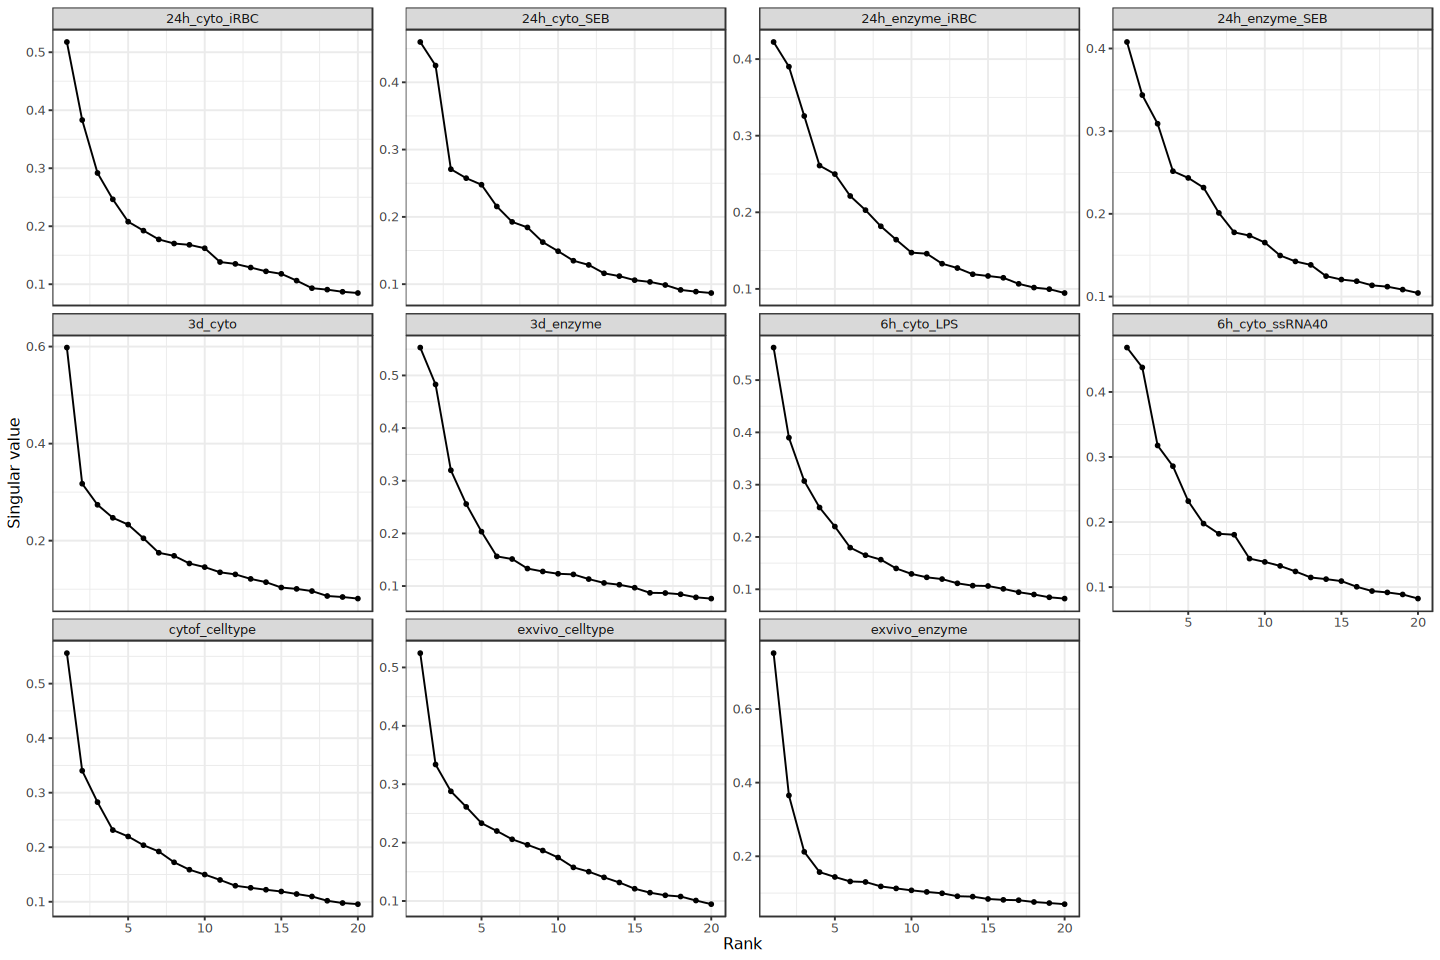

In [25]:
options(repr.plot.width = 12, repr.plot.height = 8)
scree_table |>
  dplyr::filter(.data$rank <= 20L) |>
  ggplot2::ggplot(ggplot2::aes(.data$rank, .data$singular_value)) +
  ggplot2::geom_line() +
  ggplot2::geom_point(size = 0.7) +
  ggplot2::facet_wrap(~ block, scales = "free_y", ncol = 4) +
  ggplot2::theme_bw(base_size = 9) +
  ggplot2::labs(x = "Rank", y = "Singular value")


## Primary RaJIVE fit

Primary rank selection uses Wedin plus random-direction bounds. Permutation rank selection is intentionally not used as the primary path for this paired or longitudinal design.


In [26]:
primary_fit_cache <- if (exists("repo_root") && !is.na(repo_root)) {
  file.path(repo_root, "scratch", "primary_fit.rds")
} else {
  "primary_fit.rds"
}

block_input_signature <- function(blocks) {
  lapply(blocks, function(x) {
    list(dim = dim(x), rownames = rownames(x), colnames = colnames(x))
  })
}

primary_fit_matches_blocks <- function(fit, blocks) {
  if (!inherits(fit, "rajive") || is.null(fit$block_decomps)) {
    return(FALSE)
  }
  K <- length(blocks)
  if (length(fit$block_decomps) != 3L * K) {
    return(FALSE)
  }
  component_dims <- lapply(seq_len(K), function(k) {
    dim(fit$block_decomps[[3L * (k - 1L) + 2L]]$full)
  })
  block_dims <- lapply(blocks, dim)
  dims_match <- all(mapply(identical, component_dims, block_dims))
  signature <- attr(fit, "input_signature", exact = TRUE)
  dims_match && (is.null(signature) || identical(signature, block_input_signature(blocks)))
}

fit_primary_rajive <- function(blocks, initial_signal_ranks) {
  primary_fit <- Rajive(
    blocks,
    initial_signal_ranks = as.integer(initial_signal_ranks),
    full = TRUE,
    joint_rank = NA,
    n_wedin_samples = PRIMARY_WEDIN_SAMPLES,
    n_rand_dir_samples = PRIMARY_RAND_DIR_SAMPLES,
    n_perm_samples = NA,
    num_cores = RAJIVE_NUM_CORES,
    seed = RAJIVE_SEED
  )
  attr(primary_fit, "input_signature") <- block_input_signature(blocks)
  primary_fit
}

primary_fit <- NULL
if (file.exists(primary_fit_cache)) {
  cached_fit <- readRDS(primary_fit_cache)
  if (primary_fit_matches_blocks(cached_fit, scaled_blocks)) {
    primary_fit <- cached_fit
  } else {
    message("Cached primary fit is incompatible with current scaled_blocks; refitting.")
  }
}
if (is.null(primary_fit)) {
  primary_fit <- fit_primary_rajive(scaled_blocks, initial_signal_ranks)
  dir.create(dirname(primary_fit_cache), showWarnings = FALSE, recursive = TRUE)
  saveRDS(primary_fit, primary_fit_cache)
}

summary(primary_fit)
get_all_ranks(primary_fit)


   block joint_rank individual_rank
  block1          6              10
  block2          6               9
  block3          6               3
  block4          6              10
  block5          6              13
  block6          6               4
  block7          6              12
  block8          6              13
  block9          6              12
 block10          6              10
 block11          6               7


block,joint_rank,individual_rank
<chr>,<int>,<dbl>
block1,6,10
block2,6,9
block3,6,3
block4,6,10
block5,6,13
block6,6,4
block7,6,12
block8,6,13
block9,6,12


component_index,obs_sval,obs_sval_sq,classification,joint_rank_estimate,overall_sv_sq_threshold,wedin_cutoff,rand_cutoff,perm_cutoff
<int>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,2.846615,8.103215,joint,6,3.781593,-4989,3.781593,NA
2,2.515715,6.328821,joint,6,3.781593,-4989,3.781593,NA
3,2.207511,4.873105,joint,6,3.781593,-4989,3.781593,NA
4,2.159767,4.664594,joint,6,3.781593,-4989,3.781593,NA
5,2.089868,4.367549,joint,6,3.781593,-4989,3.781593,NA
6,2.012262,4.049198,joint,6,3.781593,-4989,3.781593,NA


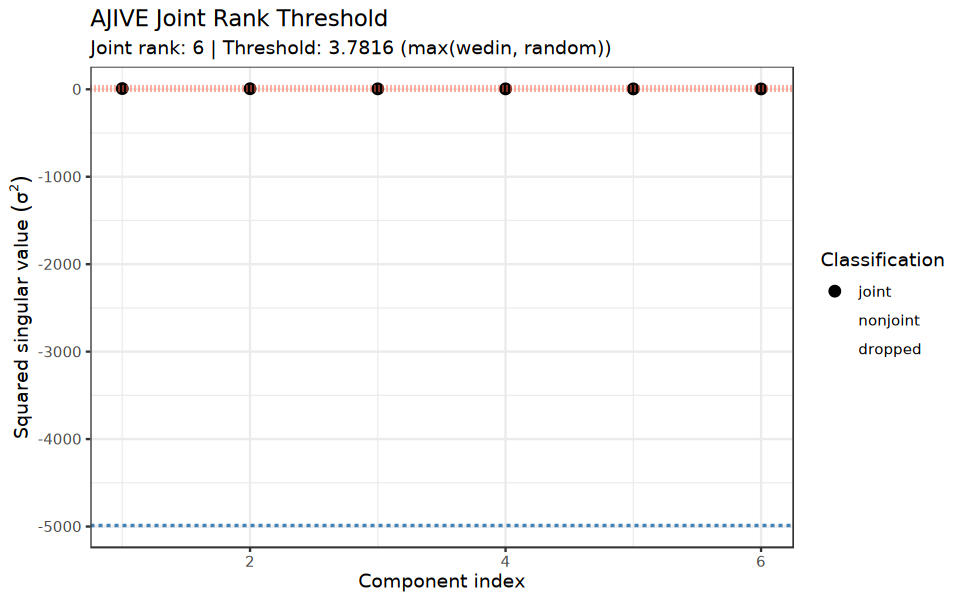

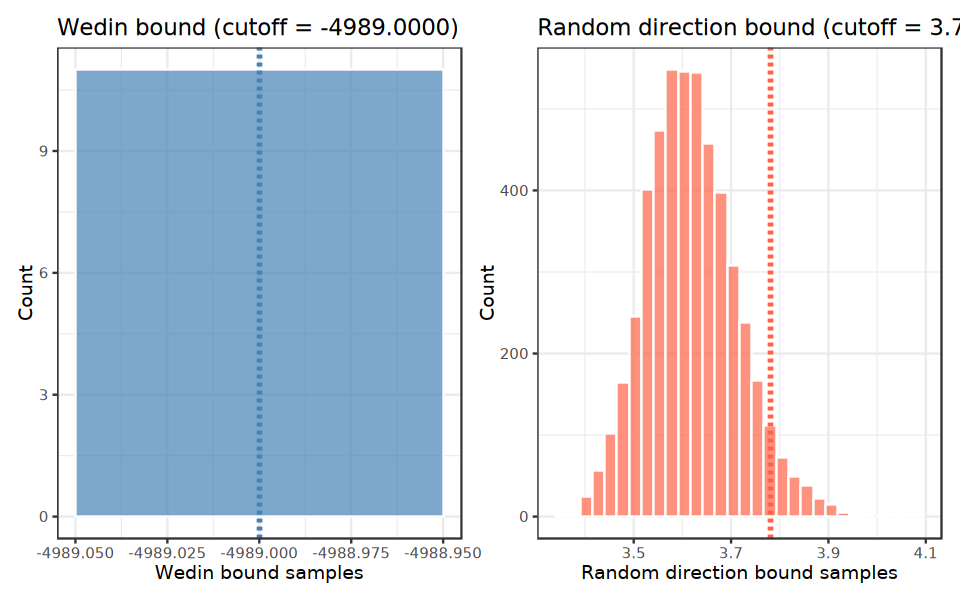

In [27]:
rank_diagnostics_wide <- extract_components(primary_fit, what = "rank_diagnostics", format = "wide")
rank_diagnostics_long <- extract_components(primary_fit, what = "rank_diagnostics", format = "long")
rank_diagnostics_long

options(repr.plot.width = 8, repr.plot.height = 5)
plot_components(primary_fit, plot_type = "rank_threshold")
plot_components(primary_fit, plot_type = "bound_distributions")


In [ ]:
variance_table <- extract_components(primary_fit, blocks = scaled_blocks, what = "variance")
joint_feature_variance <- joint_variance_partition(primary_fit, scaled_blocks)

variance_table
joint_feature_variance |>
  dplyr::group_by(.data$block) |>
  dplyr::slice_max(.data$joint_prop, n = 10, with_ties = FALSE) |>
  dplyr::ungroup()


## Rank stability gate

The observed joint rank is treated as stable when at least 70 percent of cluster bootstrap refits recover it. If not, downstream associations stay labeled rank-sensitive and forced-rank sensitivity fits are created.


In [ ]:
stability_cluster <- if ("donor_id" %in% names(metadata_analysis) && any(!is.na(metadata_analysis$donor_id))) {
  metadata_analysis$donor_id
} else {
  NULL
}

rank_stability <- assess_stability(
  primary_fit,
  blocks = scaled_blocks,
  initial_signal_ranks = as.integer(initial_signal_ranks),
  target = "joint_rank",
  B = RANK_STABILITY_B,
  cluster = stability_cluster,
  num_cores = RAJIVE_NUM_CORES,
  n_wedin_samples = STABILITY_WEDIN_SAMPLES,
  n_rand_dir_samples = STABILITY_RAND_DIR_SAMPLES,
  n_perm_samples = NA,
  seed = RAJIVE_SEED + 10L
)

rank_stability_summary <- summarize_rank_stability(rank_stability, pass_rate = RANK_STABILITY_PASS_RATE)
rank_stability_summary$summary
rank_stability_summary$table


Warning message:
“Degenerate column(s) in block 5 dropped automatically.
ℹ 1 column(s) with near-zero variance removed.”
Warning message:
“Degenerate column(s) in block 6 dropped automatically.
ℹ 5 column(s) with near-zero variance removed.”
Warning message:
“Degenerate column(s) in block 10 dropped automatically.
ℹ 1 column(s) with near-zero variance removed.”
Warning message:
“`n` is smaller than sum(initial_signal_ranks); estimation may be
underdetermined.
ℹ n = 96, sum(initial_signal_ranks) = 129”
Loading required package: foreach


Attaching package: ‘foreach’


The following objects are masked from ‘package:purrr’:

    accumulate, when


Loading required package: rngtools

Warning message:
“Degenerate column(s) in block 5 dropped automatically.
ℹ 1 column(s) with near-zero variance removed.”
Warning message:
“Degenerate column(s) in block 6 dropped automatically.
ℹ 5 column(s) with near-zero variance removed.”
Warning message:
“Degenerate column(s) in block 10 dropped automatica

In [ ]:
rank_sensitive <- isTRUE(rank_stability_summary$summary$rank_sensitive)
forced_rank_sensitivity <- NULL
if (rank_sensitive) {
  forced_rank_sensitivity <- run_forced_rank_sensitivity(
    scaled_blocks,
    initial_signal_ranks = as.integer(initial_signal_ranks),
    observed_rank = get_joint_rank(primary_fit),
    seed = RAJIVE_SEED + 20L,
    num_cores = RAJIVE_NUM_CORES
  )
  forced_rank_sensitivity$ranks
} else {
  message("Rank stability gate passed; forced-rank sensitivity fits were not run.")
}


## Jackstraw after rank audit

Feature-level jackstraw testing is run only after the primary fit and stability gate are established.


In [ ]:
if (RUN_JACKSTRAW && get_joint_rank(primary_fit) > 0L) {
  set.seed(RAJIVE_SEED + 30L)
  js <- jackstraw_rajive(
    primary_fit,
    scaled_blocks,
    alpha = JACKSTRAW_ALPHA,
    n_null = JACKSTRAW_N_NULL,
    correction = "BH"
  )
  print(summary(js))
  options(repr.plot.width = 8, repr.plot.height = 5)
  print(plot_components(jackstraw_result = js, plot_type = "jackstraw_summary"))
} else {
  js <- NULL
  message("Jackstraw skipped because RUN_JACKSTRAW is FALSE or joint rank is zero.")
}


## Exploratory component associations with current rajiveplus API

These scans use fitted component scores. They are post-decomposition exploratory associations unless bootstrap propagation and rank sensitivity checks support stability.


In [ ]:
simple_assoc_specs <- tibble::tibble(
  variable = c("study_id", "chmi_qPCR", "sex", "age_in_years", "bmi"),
  mode = c("categorical", "categorical", "categorical", "continuous", "continuous")
)

simple_assoc <- run_simple_component_associations(
  primary_fit,
  metadata = metadata_analysis,
  blocks = scaled_blocks,
  initial_signal_ranks = as.integer(initial_signal_ranks),
  specs = simple_assoc_specs,
  bootstrap = RUN_SIMPLE_ASSOC_BOOTSTRAP,
  B = SIMPLE_ASSOC_BOOTSTRAP_B,
  cluster = stability_cluster,
  num_cores = RAJIVE_NUM_CORES
)

simple_assoc |>
  dplyr::arrange(.data$p_adj) |>
  utils::head(50)

options(repr.plot.width = 9, repr.plot.height = 5)
plot_components(assoc_results = simple_assoc, plot_type = "association")


## Exact-study `dream` contrasts

The `dream` models below test the original time and protection contrasts. The joint-score model is the primary small-score analysis. Individual scores can be tested unweighted as a primary exploratory table and with array weights as sensitivity.


In [ ]:
contrast_spec <- make_exact_chmi_contrasts()
contrast_spec

dream_joint_set <- prepare_component_matrix(primary_fit, metadata_analysis, sample_ids, source = "joint")
dream_individual_set <- prepare_component_matrix(primary_fit, metadata_analysis, sample_ids, source = "individual")

validate_dream_contrasts(contrast_spec, dream_joint_set$metadata, min_n = DREAM_MIN_GROUP_N) |>
  dplyr::count(.data$valid, .data$reason)

dream_joint <- run_component_dream(
  dream_joint_set,
  contrast_spec = contrast_spec,
  use_array_weights = FALSE,
  min_group_n = DREAM_MIN_GROUP_N,
  cores = DREAM_CORES
)
joint_dream_results <- tidy_dream_results(dream_joint)

summarize_dream_hits(joint_dream_results, alpha = FDR_ALPHA, fdr_col = "fdr_family")


In [ ]:
options(repr.plot.width = 12, repr.plot.height = 5)
plot_dream_heatmap(joint_dream_results, alpha = FDR_ALPHA, fdr_col = "fdr_family", top_n = 30L)

joint_dream_results |>
  dplyr::arrange(.data$fdr_family, .data$P.Value) |>
  utils::head(50)


In [ ]:
dream_individual <- run_component_dream(
  dream_individual_set,
  contrast_spec = contrast_spec,
  use_array_weights = FALSE,
  min_group_n = DREAM_MIN_GROUP_N,
  cores = DREAM_CORES
)
individual_dream_results <- tidy_dream_results(dream_individual)

summarize_dream_hits(individual_dream_results, alpha = FDR_ALPHA, fdr_col = "fdr_family")


In [ ]:
if (RUN_ARRAY_WEIGHT_SENSITIVITY) {
  dream_individual_weighted <- run_component_dream(
    dream_individual_set,
    contrast_spec = contrast_spec,
    use_array_weights = TRUE,
    min_group_n = DREAM_MIN_GROUP_N,
    cores = DREAM_CORES
  )
  individual_dream_weighted_results <- tidy_dream_results(dream_individual_weighted)
  summarize_dream_hits(individual_dream_weighted_results, alpha = FDR_ALPHA,
                       fdr_col = "fdr_family")
} else {
  dream_individual_weighted <- NULL
  individual_dream_weighted_results <- NULL
  message("Array-weight sensitivity was skipped.")
}


In [ ]:
options(repr.plot.width = 14, repr.plot.height = 10)
plot_dream_heatmap(individual_dream_results, alpha = FDR_ALPHA,
                   fdr_col = "fdr_family", top_n = 80L)

individual_dream_results |>
  dplyr::arrange(.data$fdr_family, .data$P.Value) |>
  utils::head(80)


## Loading review after associations

Use the finalized fit and current extraction helpers for interpretable loading tables. This keeps feature names attached to the original blocks.


In [ ]:
joint_loadings <- extract_components(primary_fit, what = "loadings", type = "joint", format = "long") |>
  dplyr::mutate(block_name = names(scaled_blocks)[.data$block])

joint_loadings |>
  dplyr::group_by(.data$block, .data$component) |>
  dplyr::slice_max(abs(.data$loading), n = 20, with_ties = FALSE) |>
  dplyr::ungroup()

options(repr.plot.width = 14, repr.plot.height = 10)
plot_components(primary_fit, plot_type = "top_features", type = "joint", top_n = 20L)
